# Tugas 6 Fuzzy c-means

In [28]:
!pip install fuzzy-c-means
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD  # Import TruncatedSVD untuk reduksi dimensi
import matplotlib.pyplot as plt
from fcmeans import FCM
from sklearn.metrics import silhouette_score

In [29]:
from google.colab import files

# Upload file  dari komputer
upload_file = files.upload()

Saving teks beneran bersih rill cuy.csv to teks beneran bersih rill cuy (1).csv


In [94]:
import pandas as pd

# Membaca file CSV
file_name = 'teks beneran bersih rill cuy.csv'
df = pd.read_csv(file_name)

df.head()

,judul,tanggal,isi,kategori,cleaned_text,norm_text,token_text,swremove_text,clean_text,kategori_encoded
0,Badan Kurus Tak Berarti Bebas dari Kolesterol ...,"Kamis, 05 Sep 2024 11:03 WIB",Jakarta - Tak sedikit yang beranggapan bahwa o...,Kesehatan,Jakarta Tak sedikit yang beranggapan bahwa ora...,jakarta tidak sedikit yang beranggapan bahwa o...,"['jakarta', 'tidak', 'sedikit', 'yang', 'beran...","['jakarta', 'sedikit', 'beranggapan', 'orang',...",jakarta sedikit beranggapan orang berbadan kur...,0
1,Budaya Kerja Toksik di Jepang Picu 54 Karyawan...,"Kamis, 05 Sep 2024 10:38 WIB",Jakarta -\n \n Istilah 'bekerja ...,Kesehatan,Jakarta Istilah bekerja sampai mati nampaknya ...,jakarta istilah bekerja sampai mati nampaknya ...,"['jakarta', 'istilah', 'bekerja', 'sampai', 'm...","['jakarta', 'istilah', 'bekerja', 'mati', 'nam...",jakarta istilah bekerja mati nampaknya ssudah ...,0
2,Menyoal Serangan Jantung yang Dialami Faisal B...,"Kamis, 05 Sep 2024 10:03 WIB",Jakarta - Faisal Basri meninggal dunia. Ekonom...,Kesehatan,Jakarta Faisal Basri meninggal dunia Ekonom Un...,jakarta faisal basri meninggal dunia ekonom un...,"['jakarta', 'faisal', 'basri', 'meninggal', 'd...","['jakarta', 'faisal', 'basri', 'meninggal', 'd...",jakarta faisal basri meninggal dunia ekonom un...,0
3,Nyeri Kronis yang Bikin Paus Fransiskus Tak Bi...,"Kamis, 05 Sep 2024 09:37 WIB",Jakarta - Pemimpin tertinggi Gereja Katolik se...,Kesehatan,Jakarta Pemimpin tertinggi Gereja Katolik sedu...,jakarta pemimpin tertinggi gereja katolik sedu...,"['jakarta', 'pemimpin', 'tertinggi', 'gereja',...","['jakarta', 'pemimpin', 'tertinggi', 'gereja',...",jakarta pemimpin tertinggi gereja katolik sedu...,0
4,"Perundungan PPDS Tak Cuma Terjadi di Undip, Be...","Kamis, 05 Sep 2024 08:35 WIB",Jakarta - Aksi bullying atau perundungan di ma...,Kesehatan,Jakarta Aksi bullying atau perundungan di masa...,jakarta aksi bullying atau perundungan di masa...,"['jakarta', 'aksi', 'bullying', 'atau', 'perun...","['jakarta', 'aksi', 'bullying', 'perundungan',...",jakarta aksi bullying perundungan masa program...,0


In [95]:
texts = df['clean_text']

In [96]:
# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
X_tfidf = tfidf_matrix.toarray()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tfidf)

In [97]:
# Mendapatkan nama fitur dari TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Konversi TF-IDF hasil training ke DataFrame
df_train_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
df_train_tfidf
df_train_tfidf.to_csv("tf-idf.csv", index=False)
X_tfidf.shape

(100, 6239)

In [129]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import numpy as np

# Pastikan X_scaled sudah terdefinisi sebelumnya

# Inisialisasi variabel untuk menyimpan hasil
best_silhouette = -1
best_ari = -1
best_nmi = -1
best_n_components = 0
results = {}

# Asumsikan y_true adalah label asli dari dataset Anda
y_true = df['kategori_encoded']  # Ganti 'kategori' dengan nama kolom label asli

for n in range(2, 100):  # Rentang nilai n_components
    svd = TruncatedSVD(n_components=n, random_state=42)
    data_reduced = svd.fit_transform(X_scaled)

    # Fuzzy C-Means Clustering
    fcm = FCM(n_clusters=2, m=2.0, max_iter=1000, error=0.00001, random_state=42)
    fcm.fit(data_reduced)
    cluster_labels = fcm.predict(data_reduced)

    # Evaluasi dengan Silhouette Score, ARI, dan NMI
    silhouette = silhouette_score(data_reduced, cluster_labels)
    ari = adjusted_rand_score(y_true, cluster_labels)
    nmi = normalized_mutual_info_score(y_true, cluster_labels)

    results[n] = {
        'silhouette': silhouette,
        'ari': ari,
        'nmi': nmi
    }

    # Log setiap iterasi
    print(f"Iterasi dengan n_components={n}: Silhouette={silhouette}, ARI={ari}, NMI={nmi}")

    # Perbarui nilai terbaik
    if silhouette > best_silhouette:
        best_silhouette = silhouette
        best_n_components = n
    if ari > best_ari:
        best_ari = ari
    if nmi > best_nmi:
        best_nmi = nmi

Iterasi dengan n_components=2: Silhouette=0.9609456224110352, ARI=0.0, NMI=0.018639764244343528
Iterasi dengan n_components=3: Silhouette=0.9404878627957127, ARI=-0.0007766707522784365, NMI=0.0042289170055858855
Iterasi dengan n_components=4: Silhouette=0.9164433455314719, ARI=4.85601903559462e-05, NMI=0.012637056407904105
Iterasi dengan n_components=5: Silhouette=0.8641353965736649, ARI=0.004130624939255516, NMI=0.03348817079820381
Iterasi dengan n_components=6: Silhouette=0.8667871927985338, ARI=0.004130624939255516, NMI=0.03348817079820381
Iterasi dengan n_components=7: Silhouette=0.8249850655545596, ARI=0.007389132627638759, NMI=0.04469202501254566
Iterasi dengan n_components=8: Silhouette=0.815632615257052, ARI=0.0034364818206869723, NMI=0.023324640861378393
Iterasi dengan n_components=9: Silhouette=0.2944754484315648, ARI=0.12142123036264865, NMI=0.10805204632615578
Iterasi dengan n_components=10: Silhouette=0.10864507426457416, ARI=0.3068788249694002, NMI=0.2578242535998632
Iter

In [130]:
# Menyimpan hasil terbaik untuk setiap metrik
best_silhouette_n_components = max(results, key=lambda x: results[x]['silhouette'])
best_ari_n_components = max(results, key=lambda x: results[x]['ari'])
best_nmi_n_components = max(results, key=lambda x: results[x]['nmi'])

# Menampilkan hasil terbaik
print(f"\nBest Silhouette Score is achieved by n_components={best_silhouette_n_components} with score: {results[best_silhouette_n_components]['silhouette']}")
print(f"Best ARI is achieved by n_components={best_ari_n_components} with score: {results[best_ari_n_components]['ari']}")
print(f"Best NMI is achieved by n_components={best_nmi_n_components} with score: {results[best_nmi_n_components]['nmi']}")


Best Silhouette Score is achieved by n_components=2 with score: 0.9609456224110352
Best ARI is achieved by n_components=19 with score: 0.5430303030303031
Best NMI is achieved by n_components=19 with score: 0.4532839480340869


In [131]:
# Mengurutkan hasil berdasarkan silhouette score (dari tertinggi ke terendah)
sorted_results = sorted(results.items(), key=lambda x: x[1]['silhouette'], reverse=True)

# Menampilkan hasil akhir
print(f"\nBest n_components: {best_n_components} with silhouette score: {best_silhouette}")
print("\nAll results (sorted by silhouette score):")
for n, score in sorted_results:
    print(f"n_components={n}: Silhouette Score={score}")


Best n_components: 2 with silhouette score: 0.9609456224110352

All results (sorted by silhouette score):
n_components=2: Silhouette Score={'silhouette': 0.9609456224110352, 'ari': 0.0, 'nmi': 0.018639764244343528}
n_components=3: Silhouette Score={'silhouette': 0.9404878627957127, 'ari': -0.0007766707522784365, 'nmi': 0.0042289170055858855}
n_components=4: Silhouette Score={'silhouette': 0.9164433455314719, 'ari': 4.85601903559462e-05, 'nmi': 0.012637056407904105}
n_components=6: Silhouette Score={'silhouette': 0.8667871927985338, 'ari': 0.004130624939255516, 'nmi': 0.03348817079820381}
n_components=5: Silhouette Score={'silhouette': 0.8641353965736649, 'ari': 0.004130624939255516, 'nmi': 0.03348817079820381}
n_components=7: Silhouette Score={'silhouette': 0.8249850655545596, 'ari': 0.007389132627638759, 'nmi': 0.04469202501254566}
n_components=8: Silhouette Score={'silhouette': 0.815632615257052, 'ari': 0.0034364818206869723, 'nmi': 0.023324640861378393}
n_components=9: Silhouette S

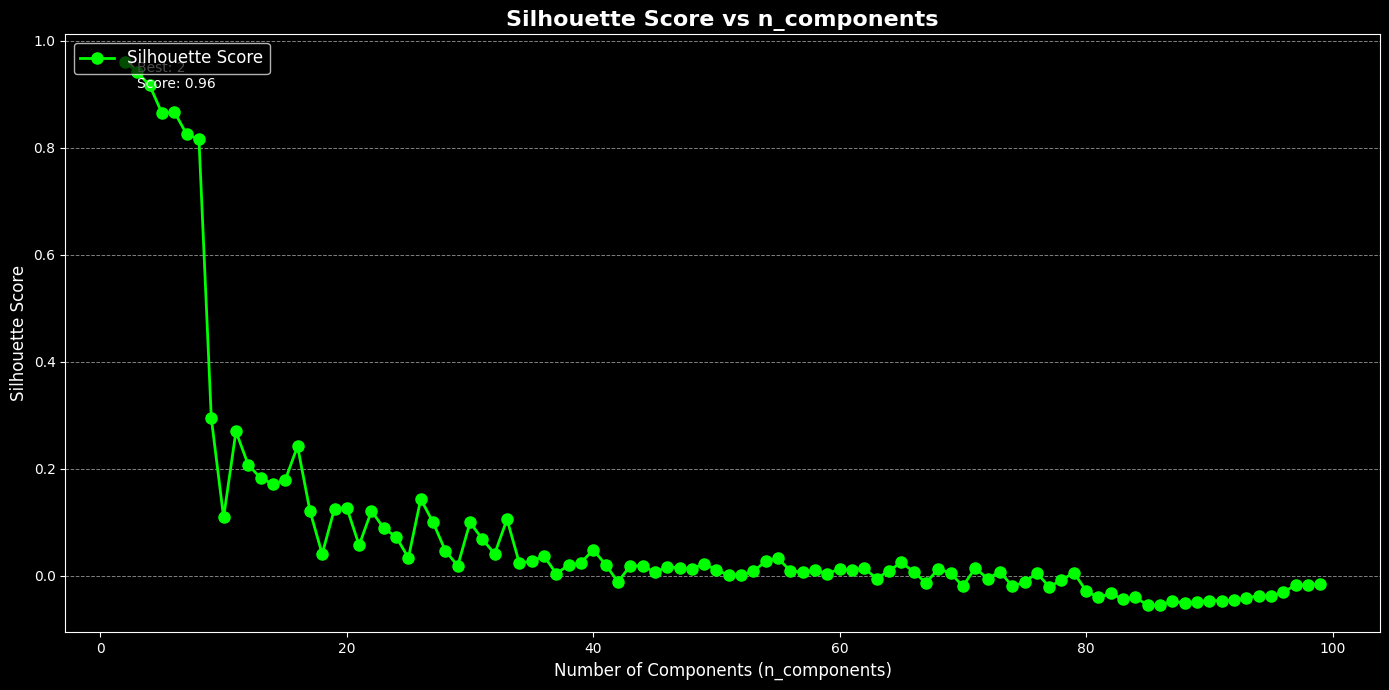

In [132]:
import matplotlib.pyplot as plt

# Data untuk plotting
n_components = list(results.keys())
silhouette_scores = [metrics['silhouette'] for metrics in results.values()]

# Ganti dengan style bawaan yang mirip
plt.style.use("dark_background")

# Membuat figure dengan nuansa grafik trading
plt.figure(figsize=(14, 7))

# Plot garis dengan marker
plt.plot(n_components, silhouette_scores, label="Silhouette Score", color="lime", linewidth=2, marker="o", markersize=8)

# Menambahkan grid horizontal
plt.grid(axis="y", color="gray", linestyle="--", linewidth=0.7)

# Menambahkan judul dan label
plt.title("Silhouette Score vs n_components", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Number of Components (n_components)", fontsize=12, color="white")
plt.ylabel("Silhouette Score", fontsize=12, color="white")

# Menambahkan anotasi untuk nilai maksimum
max_score = max(silhouette_scores)
best_n = n_components[silhouette_scores.index(max_score)]
plt.annotate(f"Best: {best_n}\nScore: {max_score:.2f}",
             xy=(best_n, max_score), xytext=(best_n + 1, max_score - 0.05),
             arrowprops=dict(facecolor='red', arrowstyle="->"),
             fontsize=10, color="white")

# Menambahkan legenda
plt.legend(fontsize=12, loc="upper left", facecolor="black", edgecolor="white", framealpha=0.7)

# Menampilkan grafik
plt.tight_layout()
plt.show()

# Clustering

In [133]:
# Membaca file CSV
file_name = 'teks beneran bersih rill cuy.csv'
df = pd.read_csv(file_name)
df

,judul,tanggal,isi,kategori,cleaned_text,norm_text,token_text,swremove_text,clean_text,kategori_encoded
0,Badan Kurus Tak Berarti Bebas dari Kolesterol ...,"Kamis, 05 Sep 2024 11:03 WIB",Jakarta - Tak sedikit yang beranggapan bahwa o...,Kesehatan,Jakarta Tak sedikit yang beranggapan bahwa ora...,jakarta tidak sedikit yang beranggapan bahwa o...,"['jakarta', 'tidak', 'sedikit', 'yang', 'beran...","['jakarta', 'sedikit', 'beranggapan', 'orang',...",jakarta sedikit beranggapan orang berbadan kur...,0
1,Budaya Kerja Toksik di Jepang Picu 54 Karyawan...,"Kamis, 05 Sep 2024 10:38 WIB",Jakarta -\n \n Istilah 'bekerja ...,Kesehatan,Jakarta Istilah bekerja sampai mati nampaknya ...,jakarta istilah bekerja sampai mati nampaknya ...,"['jakarta', 'istilah', 'bekerja', 'sampai', 'm...","['jakarta', 'istilah', 'bekerja', 'mati', 'nam...",jakarta istilah bekerja mati nampaknya ssudah ...,0
2,Menyoal Serangan Jantung yang Dialami Faisal B...,"Kamis, 05 Sep 2024 10:03 WIB",Jakarta - Faisal Basri meninggal dunia. Ekonom...,Kesehatan,Jakarta Faisal Basri meninggal dunia Ekonom Un...,jakarta faisal basri meninggal dunia ekonom un...,"['jakarta', 'faisal', 'basri', 'meninggal', 'd...","['jakarta', 'faisal', 'basri', 'meninggal', 'd...",jakarta faisal basri meninggal dunia ekonom un...,0
3,Nyeri Kronis yang Bikin Paus Fransiskus Tak Bi...,"Kamis, 05 Sep 2024 09:37 WIB",Jakarta - Pemimpin tertinggi Gereja Katolik se...,Kesehatan,Jakarta Pemimpin tertinggi Gereja Katolik sedu...,jakarta pemimpin tertinggi gereja katolik sedu...,"['jakarta', 'pemimpin', 'tertinggi', 'gereja',...","['jakarta', 'pemimpin', 'tertinggi', 'gereja',...",jakarta pemimpin tertinggi gereja katolik sedu...,0
4,"Perundungan PPDS Tak Cuma Terjadi di Undip, Be...","Kamis, 05 Sep 2024 08:35 WIB",Jakarta - Aksi bullying atau perundungan di ma...,Kesehatan,Jakarta Aksi bullying atau perundungan di masa...,jakarta aksi bullying atau perundungan di masa...,"['jakarta', 'aksi', 'bullying', 'atau', 'perun...","['jakarta', 'aksi', 'bullying', 'perundungan',...",jakarta aksi bullying perundungan masa program...,0
...,...,...,...,...,...,...,...,...,...,...
95,"Iwh, Pekerja Speedboat Thailand Pamer BAB ke L...","Rabu, 04 Sep 2024 05:01 WIB",Jakarta - Warga Thailand dibuat jijik dengan k...,Pariwisata,Jakarta Warga Thailand dibuat jijik dengan kel...,jakarta warga thailand dibuat jijik dengan kel...,"['jakarta', 'warga', 'thailand', 'dibuat', 'ji...","['jakarta', 'warga', 'thailand', 'dibuat', 'ji...",jakarta warga thailand dibuat jijik kelakuan s...,1
96,"Ogah Bayar Layanan, 3 Turis Palestina Keroyok ...","Selasa, 03 Sep 2024 21:05 WIB",Taba - Seorang staf hotel di Mesir tewas usai ...,Pariwisata,Taba Seorang staf hotel di Mesir tewas usai be...,taba seorang staf hotel di mesir tewas usai be...,"['taba', 'seorang', 'staf', 'hotel', 'di', 'me...","['taba', 'seorang', 'staf', 'hotel', 'mesir', ...",taba seorang staf hotel mesir tewas usai berke...,1
97,"Licik, Keluarga Taruh Kecoa di Piring Agar Mak...","Selasa, 03 Sep 2024 20:37 WIB",Jakarta - Keluarga asal Meksiko dituduh melaku...,Pariwisata,Jakarta Keluarga asal Meksiko dituduh melakuka...,jakarta keluarga asal meksiko dituduh melakuka...,"['jakarta', 'keluarga', 'asal', 'meksiko', 'di...","['jakarta', 'keluarga', 'asal', 'meksiko', 'di...",jakarta keluarga asal meksiko dituduh melakuka...,1
98,"Terulang Lagi, Triatlon Paralimpiade Ditunda g...","Selasa, 03 Sep 2024 20:05 WIB","Paris - Saat Olimpiade Paris 2024 lalu, kompet...",Pariwisata,Paris Saat Olimpiade Paris lalu kompetisi tria...,paris saat olimpiade paris lalu kompetisi tria...,"['paris', 'saat', 'olimpiade', 'paris', 'lalu'...","['paris', 'olimpiade', 'paris', 'lalu', 'kompe...",paris olimpiade paris lalu kompetisi triatlon ...,1


Silhouette Score: 0.0723
Jumlah data pada setiap cluster:
Cluster
0    55
1    45
Name: count, dtype: int64


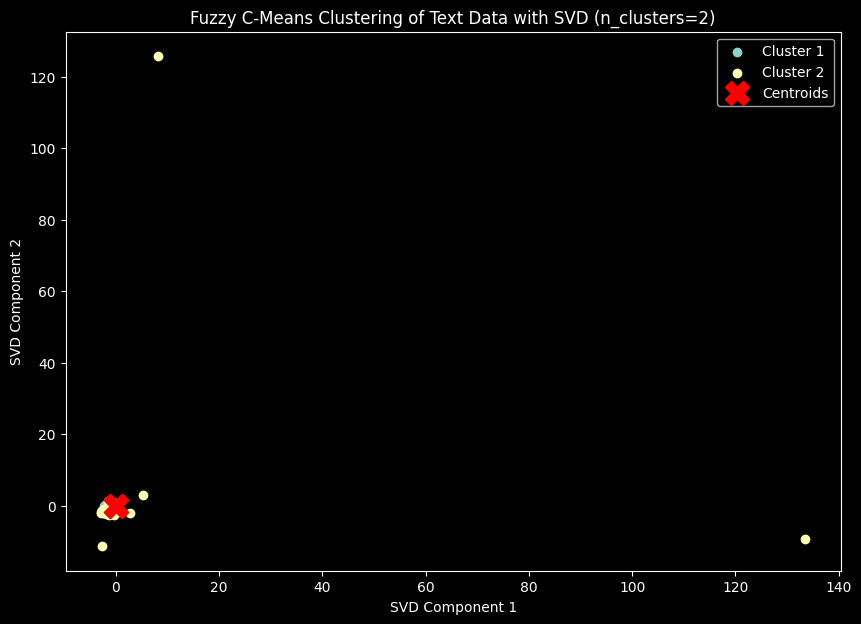

In [139]:
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

random_seed = 42  # Tetapkan seed untuk konsistensi

# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])
tfidf = tfidf_matrix.toarray()

# Step 3: Normalisasi Hasil TF-IDF
scaler = StandardScaler()
data_normalisasi = scaler.fit_transform(tfidf)

# Step 4: Reduksi dimensi menggunakan SVD
svd = TruncatedSVD(n_components=24, random_state=random_seed)  # Dimensi diatur ke 2 untuk visualisasi
data_cluster = svd.fit_transform(data_normalisasi)

# Fuzzy C-Means Clustering
n_clusters = 2  # Ganti sesuai kebutuhan
fcm = FCM(n_clusters=n_clusters, m=2.0, max_iter=1000, epsilon=0.00001, random_state=random_seed)
fcm.fit(data_cluster)

# Mendapatkan hasil clustering
membership = fcm.u
cluster_labels = np.argmax(membership, axis=1)  # Menentukan cluster untuk setiap data

# Tambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels

# Tampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()

# Hitung Silhouette Score
silhouette_avg = silhouette_score(data_cluster, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.4f}")

# Cetak hasil jumlah data per cluster
print("Jumlah data pada setiap cluster:")
print(cluster_counts)

# Visualisasi hasil clustering
plt.figure(figsize=(10, 7))

# Plot titik data dalam ruang 2D yang sudah direduksi, dengan warna berdasarkan cluster
for i in range(n_clusters):
    cluster_data = data_cluster[cluster_labels == i]  # Filter data per cluster
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], label=f'Cluster {i+1}')

# Plot centroid
cluster_centers = fcm.centers
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title(f'Fuzzy C-Means Clustering of Text Data with SVD (n_clusters={n_clusters})')
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.legend()
plt.show()

In [140]:
# Menambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels
df

,judul,tanggal,isi,kategori,cleaned_text,norm_text,token_text,swremove_text,clean_text,kategori_encoded,Cluster,id
0,Badan Kurus Tak Berarti Bebas dari Kolesterol ...,"Kamis, 05 Sep 2024 11:03 WIB",Jakarta - Tak sedikit yang beranggapan bahwa o...,Kesehatan,Jakarta Tak sedikit yang beranggapan bahwa ora...,jakarta tidak sedikit yang beranggapan bahwa o...,"['jakarta', 'tidak', 'sedikit', 'yang', 'beran...","['jakarta', 'sedikit', 'beranggapan', 'orang',...",jakarta sedikit beranggapan orang berbadan kur...,0,1,0
1,Budaya Kerja Toksik di Jepang Picu 54 Karyawan...,"Kamis, 05 Sep 2024 10:38 WIB",Jakarta -\n \n Istilah 'bekerja ...,Kesehatan,Jakarta Istilah bekerja sampai mati nampaknya ...,jakarta istilah bekerja sampai mati nampaknya ...,"['jakarta', 'istilah', 'bekerja', 'sampai', 'm...","['jakarta', 'istilah', 'bekerja', 'mati', 'nam...",jakarta istilah bekerja mati nampaknya ssudah ...,0,0,1
2,Menyoal Serangan Jantung yang Dialami Faisal B...,"Kamis, 05 Sep 2024 10:03 WIB",Jakarta - Faisal Basri meninggal dunia. Ekonom...,Kesehatan,Jakarta Faisal Basri meninggal dunia Ekonom Un...,jakarta faisal basri meninggal dunia ekonom un...,"['jakarta', 'faisal', 'basri', 'meninggal', 'd...","['jakarta', 'faisal', 'basri', 'meninggal', 'd...",jakarta faisal basri meninggal dunia ekonom un...,0,1,2
3,Nyeri Kronis yang Bikin Paus Fransiskus Tak Bi...,"Kamis, 05 Sep 2024 09:37 WIB",Jakarta - Pemimpin tertinggi Gereja Katolik se...,Kesehatan,Jakarta Pemimpin tertinggi Gereja Katolik sedu...,jakarta pemimpin tertinggi gereja katolik sedu...,"['jakarta', 'pemimpin', 'tertinggi', 'gereja',...","['jakarta', 'pemimpin', 'tertinggi', 'gereja',...",jakarta pemimpin tertinggi gereja katolik sedu...,0,0,3
4,"Perundungan PPDS Tak Cuma Terjadi di Undip, Be...","Kamis, 05 Sep 2024 08:35 WIB",Jakarta - Aksi bullying atau perundungan di ma...,Kesehatan,Jakarta Aksi bullying atau perundungan di masa...,jakarta aksi bullying atau perundungan di masa...,"['jakarta', 'aksi', 'bullying', 'atau', 'perun...","['jakarta', 'aksi', 'bullying', 'perundungan',...",jakarta aksi bullying perundungan masa program...,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...
95,"Iwh, Pekerja Speedboat Thailand Pamer BAB ke L...","Rabu, 04 Sep 2024 05:01 WIB",Jakarta - Warga Thailand dibuat jijik dengan k...,Pariwisata,Jakarta Warga Thailand dibuat jijik dengan kel...,jakarta warga thailand dibuat jijik dengan kel...,"['jakarta', 'warga', 'thailand', 'dibuat', 'ji...","['jakarta', 'warga', 'thailand', 'dibuat', 'ji...",jakarta warga thailand dibuat jijik kelakuan s...,1,0,95
96,"Ogah Bayar Layanan, 3 Turis Palestina Keroyok ...","Selasa, 03 Sep 2024 21:05 WIB",Taba - Seorang staf hotel di Mesir tewas usai ...,Pariwisata,Taba Seorang staf hotel di Mesir tewas usai be...,taba seorang staf hotel di mesir tewas usai be...,"['taba', 'seorang', 'staf', 'hotel', 'di', 'me...","['taba', 'seorang', 'staf', 'hotel', 'mesir', ...",taba seorang staf hotel mesir tewas usai berke...,1,0,96
97,"Licik, Keluarga Taruh Kecoa di Piring Agar Mak...","Selasa, 03 Sep 2024 20:37 WIB",Jakarta - Keluarga asal Meksiko dituduh melaku...,Pariwisata,Jakarta Keluarga asal Meksiko dituduh melakuka...,jakarta keluarga asal meksiko dituduh melakuka...,"['jakarta', 'keluarga', 'asal', 'meksiko', 'di...","['jakarta', 'keluarga', 'asal', 'meksiko', 'di...",jakarta keluarga asal meksiko dituduh melakuka...,1,1,97
98,"Terulang Lagi, Triatlon Paralimpiade Ditunda g...","Selasa, 03 Sep 2024 20:05 WIB","Paris - Saat Olimpiade Paris 2024 lalu, kompet...",Pariwisata,Paris Saat Olimpiade Paris lalu kompetisi tria...,paris saat olimpiade paris lalu kompetisi tria...,"['paris', 'saat', 'olimpiade', 'paris', 'lalu'...","['paris', 'olimpiade', 'paris', 'lalu', 'kompe...",paris olimpiade paris lalu kompetisi triatlon ...,1,1,98


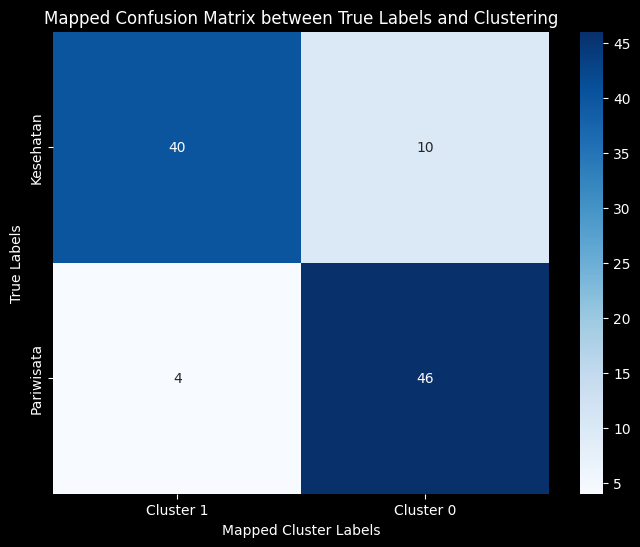

Mapped Confusion Matrix:
[[40 10]
 [ 4 46]]


In [141]:
from scipy.optimize import linear_sum_assignment

# Terapkan Hungarian Algorithm untuk memetakan cluster ke label asli
row_ind, col_ind = linear_sum_assignment(-conf_matrix)  # Maksimalkan kesesuaian

# Buat confusion matrix yang sudah dimapping
mapped_conf_matrix = conf_matrix[:, col_ind]

# Tampilkan confusion matrix yang telah dimapping menggunakan heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(mapped_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Cluster {col}" for col in col_ind],  # Cluster sesuai mapping
            yticklabels=label_encoder.classes_)  # True labels tetap
plt.title('Mapped Confusion Matrix between True Labels and Clustering')
plt.xlabel('Mapped Cluster Labels')
plt.ylabel('True Labels')
plt.show()

# Cetak confusion matrix yang telah dimapping secara numerik
print("Mapped Confusion Matrix:")
print(mapped_conf_matrix)


In [142]:
# Tambahkan kolom ID jika belum ada
df['id'] = df.index

# Ambil kolom id, kategori_encoded, dan Cluster
selected_columns = df[['id', 'kategori_encoded', 'Cluster']]

# Tampilkan DataFrame yang hanya berisi kolom yang dipilih
print(selected_columns)

    id  kategori_encoded  Cluster
0    0                 0        1
1    1                 0        0
2    2                 0        1
3    3                 0        0
4    4                 0        0
..  ..               ...      ...
95  95                 1        0
96  96                 1        0
97  97                 1        1
98  98                 1        1
99  99                 1        1

[100 rows x 3 columns]


In [143]:
# Ambil semua anggota Cluster 0
cluster_0 = selected_columns[selected_columns['Cluster'] == 0]['id'].tolist()

# Ambil semua anggota Cluster 1
cluster_1 = selected_columns[selected_columns['Cluster'] == 1]['id'].tolist()

# Tampilkan hasil dalam bentuk list
print("Anggota Cluster 0:", cluster_0)
print("Anggota Cluster 1:", cluster_1)

Anggota Cluster 0: [1, 3, 4, 6, 8, 9, 10, 12, 13, 17, 19, 20, 21, 23, 24, 26, 27, 29, 31, 32, 35, 37, 39, 40, 41, 42, 43, 44, 51, 54, 55, 57, 58, 62, 64, 66, 67, 68, 69, 70, 72, 73, 75, 77, 78, 80, 81, 82, 84, 85, 90, 91, 94, 95, 96]
Anggota Cluster 1: [0, 2, 5, 7, 11, 14, 15, 16, 18, 22, 25, 28, 30, 33, 34, 36, 38, 45, 46, 47, 48, 49, 50, 52, 53, 56, 59, 60, 61, 63, 65, 71, 74, 76, 79, 83, 86, 87, 88, 89, 92, 93, 97, 98, 99]
